# Coursework 1 Group (text)

Group number: 28

Student names and k-numbers:
1. Daniel Rolon Rodriguez - K2552225
2. Syed Johar Abbas - K2604504
3. Dominic Cummins - K1427123

# Load modules (code)

In [28]:
# Data import
from sklearn.datasets import fetch_openml

# Data handling
import numpy as np
import pandas as pd
import sklearn
from collections import Counter

# Feature pre-processing
from sklearn.preprocessing import(
    StandardScaler,
    LabelEncoder,
    label_binarize
)
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Model and training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    ExtraTreesClassifier,
    VotingClassifier
    )
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

#Validation
from sklearn.model_selection import(
    GridSearchCV,
    RandomizedSearchCV
)

#Evaluation
from sklearn.metrics import(
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Load data (code)

## Loading

In [5]:
#Loading data
dataset = fetch_openml(data_id=4538, as_frame=False)
X = dataset.data.astype(float)
y = dataset.target

#Loading data for visualisation
df = pd.DataFrame(X, columns=dataset.feature_names)
df['phase'] = y


## Data analysis

### Class balance observation

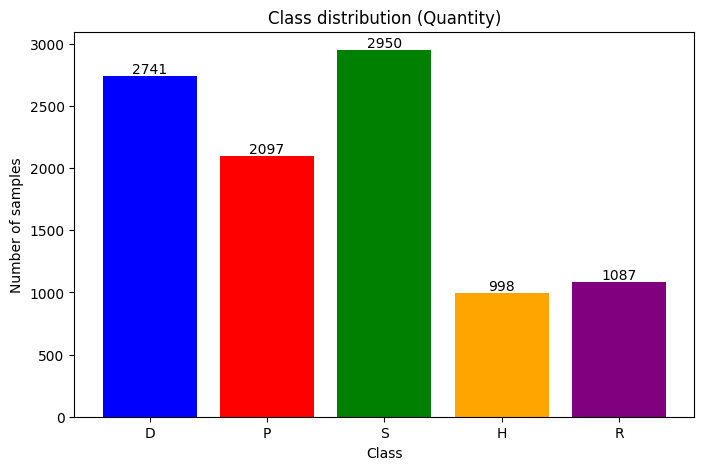

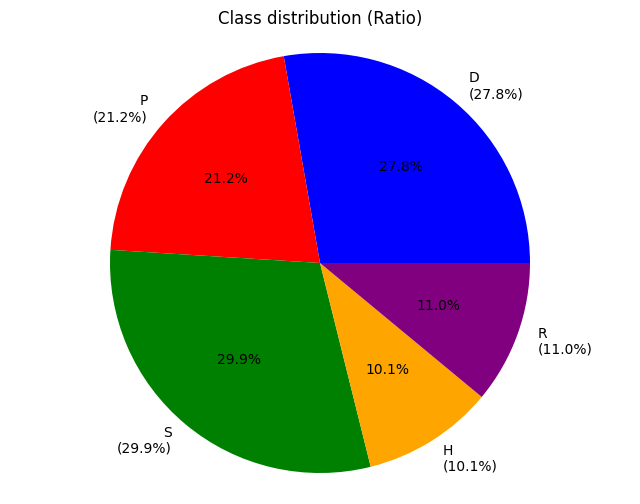

In [17]:
class_counts = Counter(y)
classes = ['D', 'P', 'S', 'H', 'R']
counts = [class_counts.get(c, 0) for c in classes]

#Quantity comparison (bar)
plt.figure(figsize=(8,5))
plt.bar(classes, counts,  color=['blue', 'red', 'green', 'orange', 'purple'])
plt.title('Class distribution (Quantity)')
plt.xlabel('Class')
plt.ylabel('Number of samples')
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center')
plt.show()

#Ratio comparison (pie)
total = sum(counts)
percentages = [count/total*100 for count in counts]
labels  = [f'{c}\n({p:.1f}%)' for c, p in zip(classes, percentages)]
plt.figure(figsize=(8,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['blue', 'red', 'green', 'orange', 'purple'])
plt.title('Class distribution (Ratio)')
plt.axis('equal')
plt.show()

### Correlation analysis

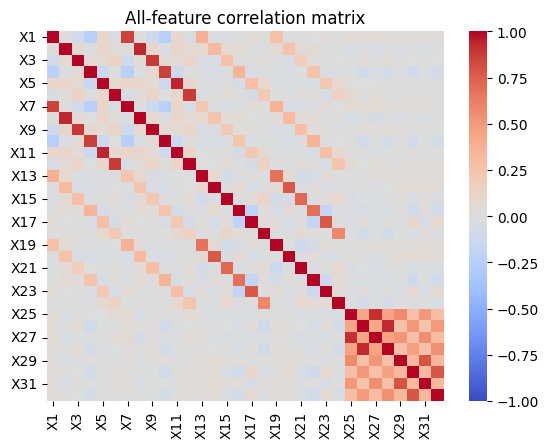

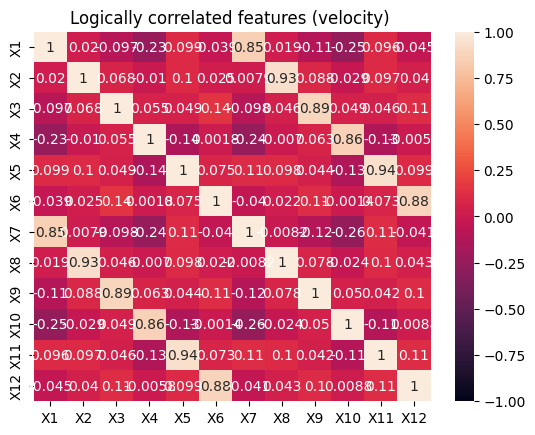

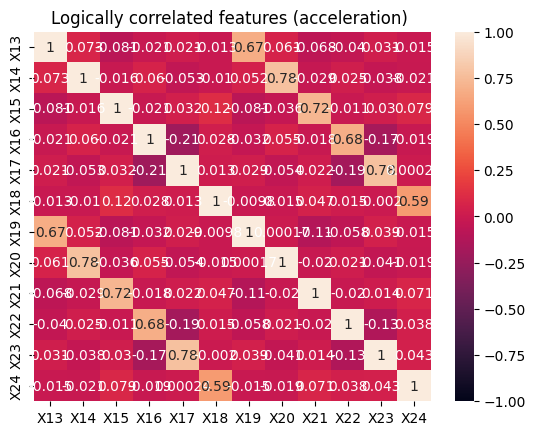

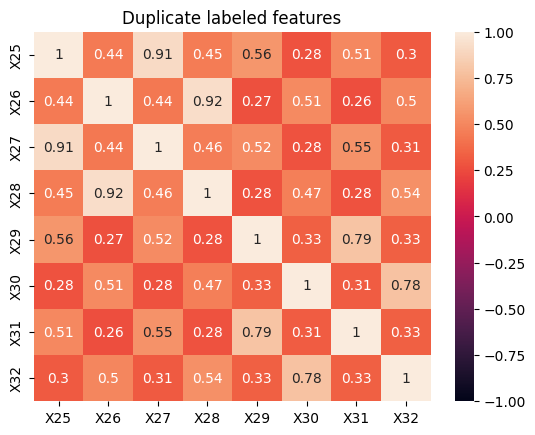

In [4]:
#Feature correlation matrix
corr_matrix = df.iloc[:, :-1].astype(float).corr()
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("All-feature correlation matrix")
plt.show()

#Logical correlation matrix (Velocity)
velocity_set = df.iloc[:, 0:12].astype(float)
corr_velocity = velocity_set.corr()
sns.heatmap(corr_velocity, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (velocity) ")
plt.show()

#Logical correlation matrix (Acceleration)
acceleration_set = df.iloc[:, 12:24].astype(float)
corr_acceleration = acceleration_set.corr()
sns.heatmap(corr_acceleration, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (acceleration) ")
plt.show()

#Duplicate label correlation matrix
duplicate_set = df.iloc[:, 24:32].astype(float)
corr_duplicates = duplicate_set.corr()
sns.heatmap(corr_duplicates, annot=True, vmin =-1, vmax=1)
plt.title("Duplicate labeled features")
plt.show()

### Scalar duplicates analysis
In the dataset, the last group of features, (X25 - X32) Scalar velocities, are labelleled twice (X25 - 28) & (X29 - X32), this analysis intends to determine what those last four features truly are.
Based on the structure of the dataset, the hypothesis is that they are actually acceleration, not velocity, as acceleration has consistently followed after velocity throughout the structure and acceleration does not have a scalar  format.

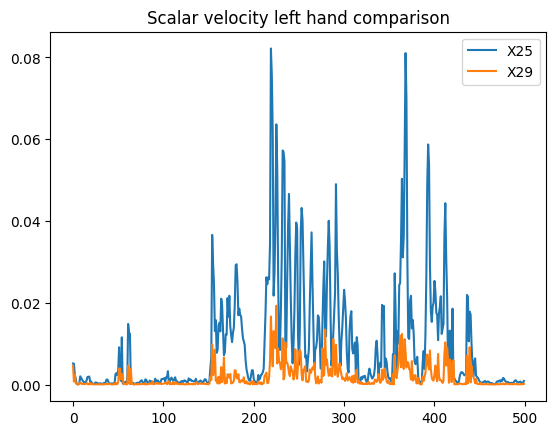

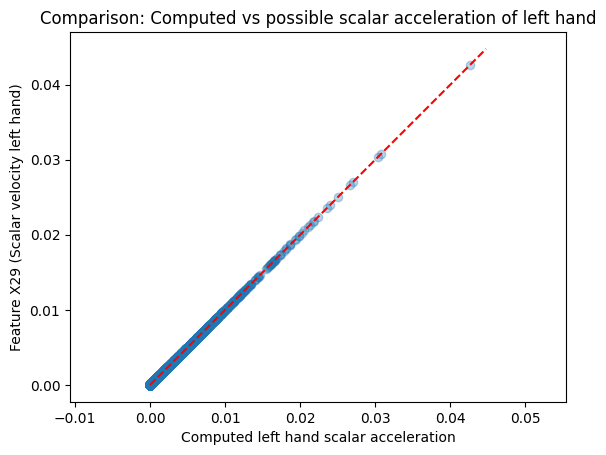

In [5]:
#Duplicate comparison
plt.plot(df['X25'].iloc[:500], label ='X25')
plt.plot(df['X29'].iloc[:500], label ='X29')
plt.legend()
plt.title("Scalar velocity left hand comparison")
plt.show()

#Testing hypothesis
left_scalar_acc = np.sqrt(df['X13']**2 +  df['X14']**2 + df['X15']**2)
plt.scatter(left_scalar_acc, df['X29'], alpha=0.3)
plt.xlabel('Computed left hand scalar acceleration')
plt.ylabel('Feature X29 (Scalar velocity left hand)')
plt.title('Comparison: Computed vs possible scalar acceleration of left hand')
plt.plot([0, plt.xlim()[1]], [0, plt.xlim()[1]], 'r--')
plt.axis('equal')
plt.show()


### Class trends analysis

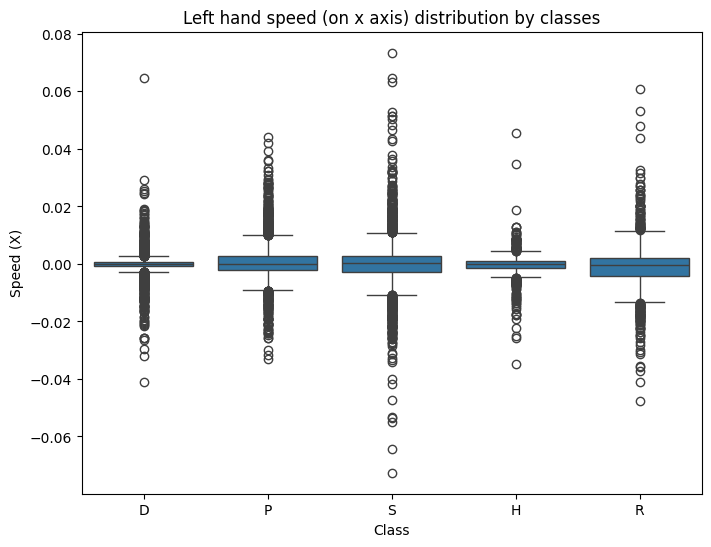

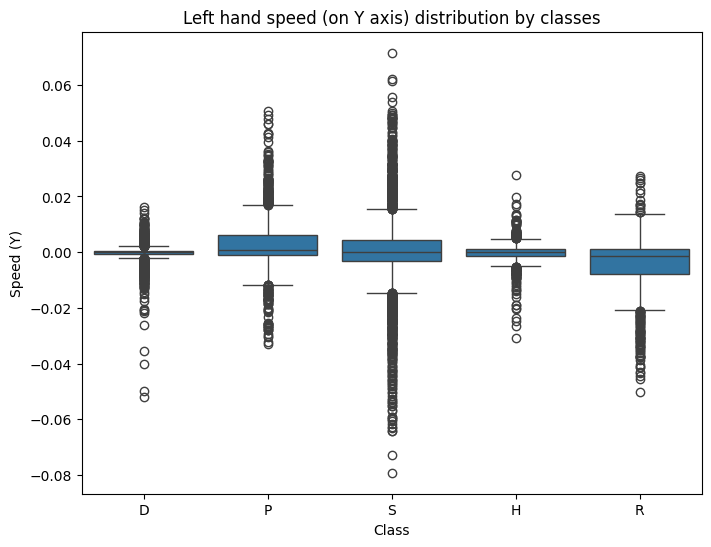

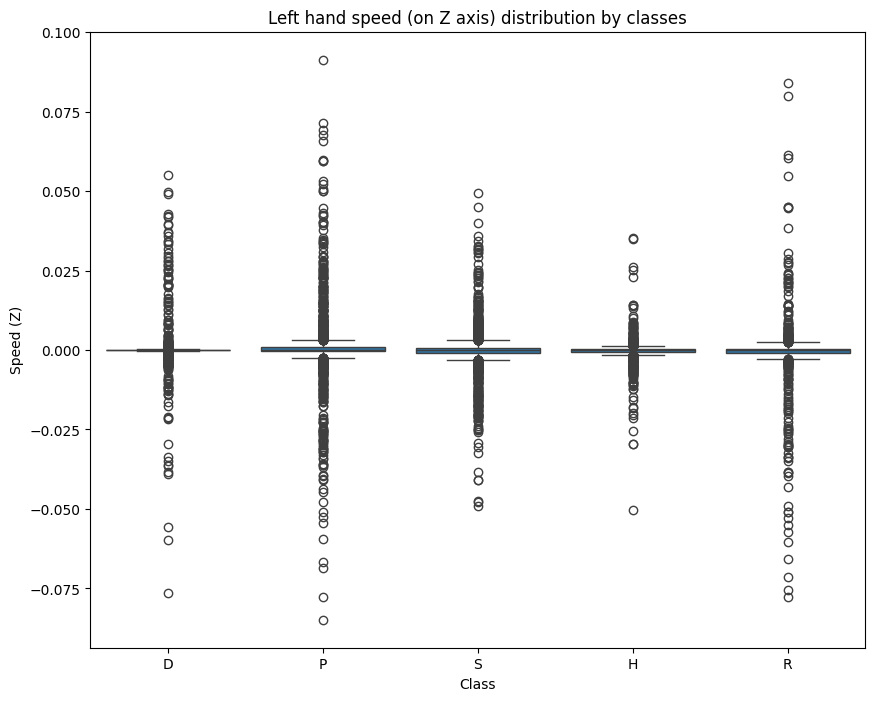

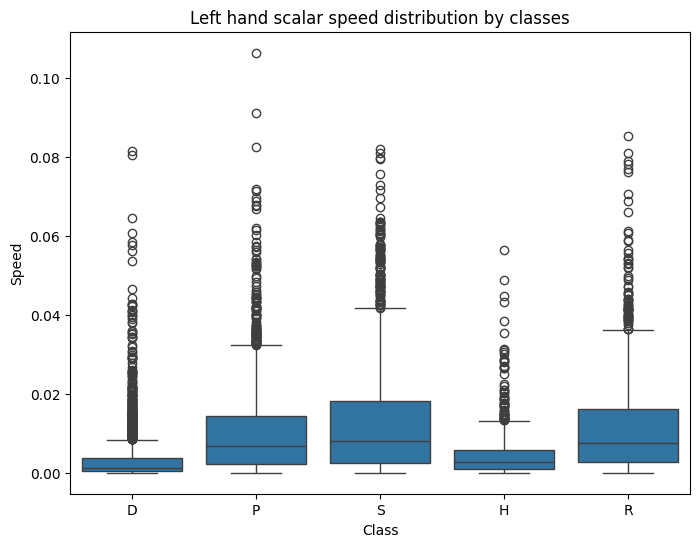

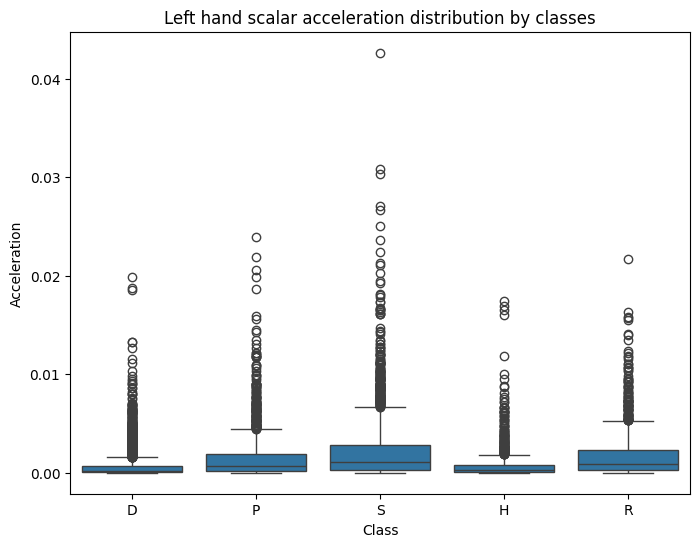

In [6]:
#Vectorial velocity analysis
#X
plt.figure(figsize=(8,6))
sns.boxplot(data=df,  x='phase', y='X1')
plt.ylabel('Speed (X)')
plt.xlabel('Class')
plt.title('Left hand speed (on x axis) distribution by classes')
plt.show()

#Y
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y='X2')
plt.ylabel('Speed (Y)')
plt.xlabel('Class')
plt.title('Left hand speed (on Y axis) distribution by classes')
plt.show()

#Z
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x='phase', y='X3')
plt.ylabel('Speed (Z)')
plt.xlabel('Class')
plt.title('Left hand speed (on Z axis) distribution by classes')
plt.show()

#Scalar analysis
#Velocity
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y = 'X25')
plt.ylabel('Speed')
plt.xlabel('Class')
plt.title('Left hand scalar speed distribution by classes')
plt.show()

#Acceleration
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y = 'X29')
plt.ylabel('Acceleration')
plt.xlabel('Class')
plt.title('Left hand scalar acceleration distribution by classes')
plt.show()

### Feature engineering for class trend analysis

#### Feature 1, Hand wrist alignment (dot product)

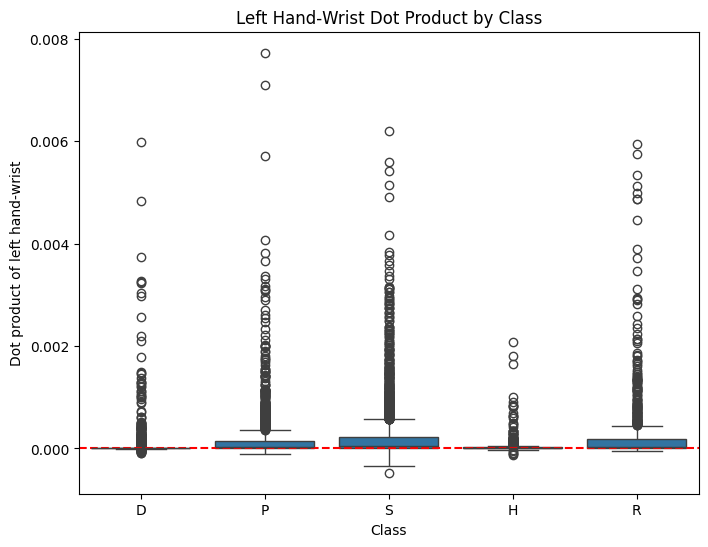

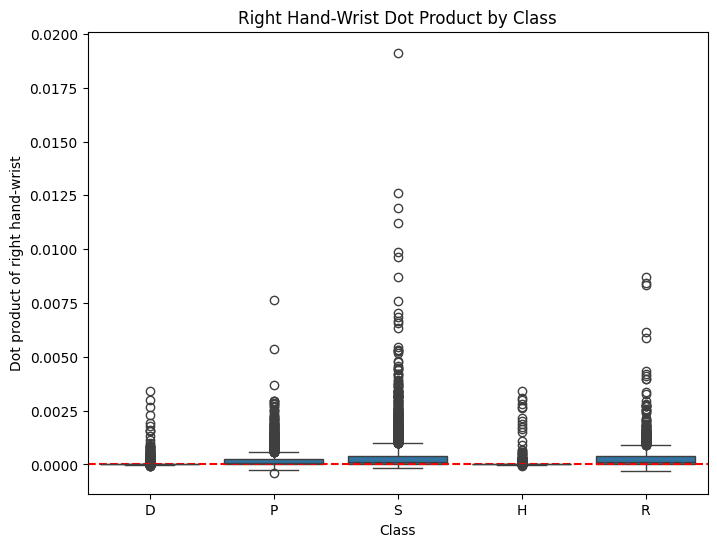

In [7]:
#Left dot
left_dot = (df['X1'] * df['X7']+
            df['X2'] * df['X8']+
            df['X3'] * df['X9'])

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=left_dot)
plt.title('Left Hand‑Wrist Dot Product by Class')
plt.ylabel('Dot product of left hand-wrist')
plt.xlabel('Class')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

#Right dot
right_dot = (df['X4'] * df['X10']+
            df['X5'] * df['X11']+
            df['X6'] * df['X12'])

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=right_dot)
plt.title('Right Hand‑Wrist Dot Product by Class')
plt.ylabel('Dot product of right hand-wrist')
plt.xlabel('Class')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

#### Feature 2 Left/Right hand movement ratio

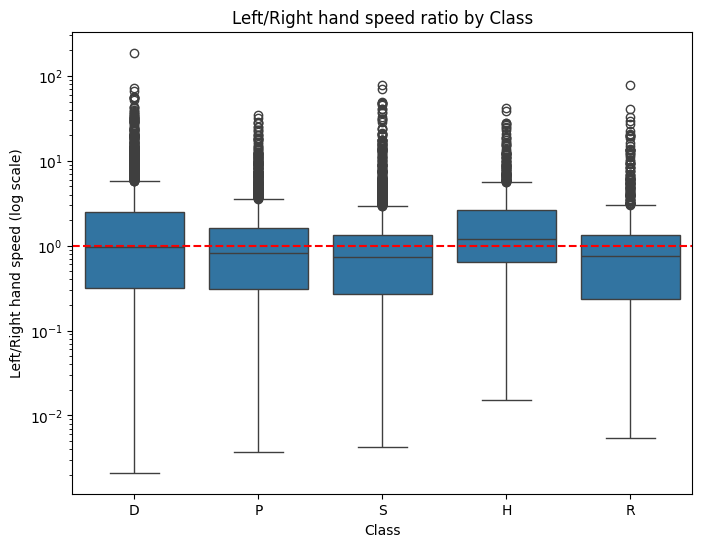

In [8]:
epsilon = 1e-8
left_right_vel_ratio = df['X25'] / (df['X26'] + epsilon)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=left_right_vel_ratio)
plt.yscale('log')
plt.title('Left/Right hand speed ratio by Class')
plt.ylabel('Left/Right hand speed (log scale)')
plt.xlabel('Class')
plt.axhline(y=1, color='red', linestyle='--')
plt.show()

## Data pre processing

### Data splitting

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

### Data reformatting

#### Label encoding

In [7]:
class_encoder = LabelEncoder()

y_train_encoded = class_encoder.fit_transform(y_train)
y_test_encoded = class_encoder.fit_transform(y_test)

####  Scaling

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### PCA + Analysis

PCA results => (20, 32)
Variance ratio =>
 [0.13406234 0.09512721 0.08200879 0.07713089 0.06910493 0.06327387
 0.05956676 0.05156825 0.04715807 0.04517631 0.03973526 0.0375281
 0.03233905 0.03029897 0.02652673 0.01816501 0.01408145 0.01230116
 0.01058476 0.00899126]


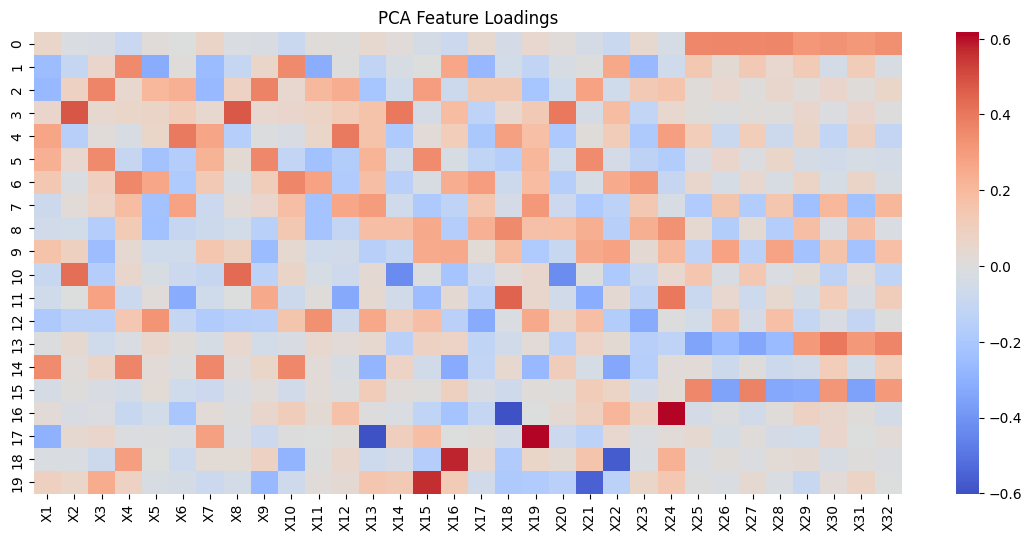

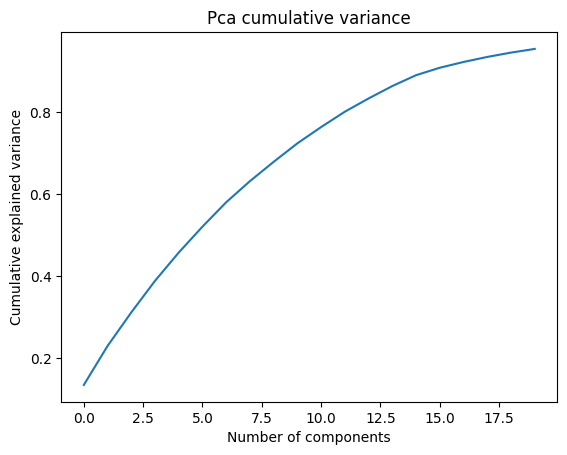

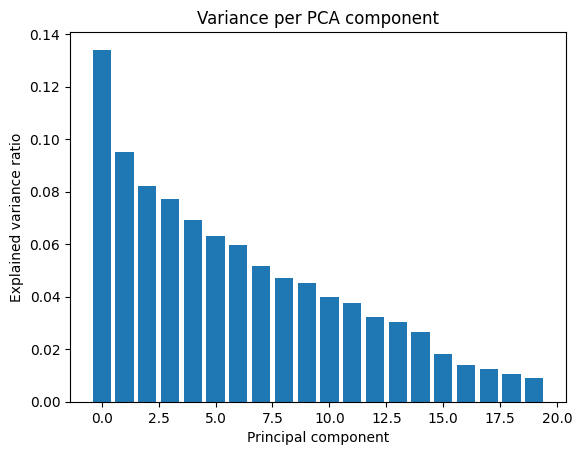

In [11]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("PCA results =>", pca.components_.shape)
print("Variance ratio =>\n", pca.explained_variance_ratio_)

#Loadings matrix
loadings = pd.DataFrame(
    pca.components_,
    columns=dataset.feature_names
)
plt.figure(figsize=(14, 6))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("PCA Feature Loadings")
plt.show()

#Variance graphs
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Pca cumulative variance")
plt.show()

plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance per PCA component")
plt.show()

#### Feature implementation

In [67]:
def add_engineered_features(X, epsilon=1e-8):
    left_dot_np  = X[:, 0] * X[:, 6] + X[:, 1] * X[:, 7] + X[:, 2] * X[:, 8]
    right_dot_np = X[:, 3] * X[:, 9] + X[:, 4] * X[:, 10] + X[:, 5] * X[:, 11]
    lr_ratio_np = X[:, 24] / (X[:, 25] + epsilon)

    left_dot_np = left_dot_np.reshape(-1, 1)
    right_dot_np = right_dot_np.reshape(-1,  1)
    lr_ratio_np = lr_ratio_np.reshape(-1, 1)

    X_augmented = np.hstack([X, left_dot_np, right_dot_np, lr_ratio_np])
    return X_augmented

X_train_augmented = add_engineered_features(X_train)
X_test_augmented = add_engineered_features(X_test)

print("Original train set: ", X_train.shape)
print("Original test set: ", X_test.shape)

print("New train set: ", X_train_augmented.shape)
print("New test set: ", X_test_augmented.shape)

Original train set:  (6911, 32)
Original test set:  (2962, 32)
New train set:  (6911, 35)
New test set:  (2962, 35)


# Classification

## Classification methods used (text)

Mention the classification methods used below. You should not describe them, but if they have not been discussed in the class, you should cite the source:


1.   Logistic Regression classifier
2.   Support Vector Machine
3.   Extra Trees Classifier
4.   Light Gradient Boosting Machine
5.   eXtreme Gradient Boosting
6.   XGBoost + SMOTE balancing
7.   LGBM + Feature implemented
8.   Voting classifier

## Training (code)

#### Logistic Regression

In [35]:
log_csf = LogisticRegression(max_iter=10000, solver='lbfgs', class_weight='balanced')
log_csf.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

#### Support Vector Machine

In [37]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_param_grid = {
        'C' : [5, 10, 20],
        'gamma': [0.05, 0.1, 0.2],
}
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_svm.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...bability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [5, 10, ...], 'gamma': [0.05, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the f

### Extra Trees

In [45]:
etc = ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
etc_param_grid_RS = {
    'n_estimators': [800,  900, 1000, 1100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [4,5,6,7],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt', 'log2', 0.5]
}

etc_RS = RandomizedSearchCV(
    estimator=etc,
    param_distributions=etc_param_grid_RS,
    n_iter=100,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

etc_RS.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [4, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

### Light Gradient Boosting Machine 

In [109]:
lgbm = LGBMClassifier(random_state=42, n_jobs=-1)

lgbm_param_dist = {
    'num_leaves': [60, 70, 80, 90],
    'max_depth': [None, 9, 10, 11, 12],
    'learning_rate': [0.05, 0.075, 0.08, 0.085],
    'n_estimators': [400, 500, 600, 700],
    'min_child_samples': [20, 30, 40],
    'subsample': [0.6, 0.7, 0.8,],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.1, 0.2, 0.3,],
    'reg_lambda':[ 0.4, 0.5, 0.6, 0.7],
    'class_weight': ['balanced']
}

lgbm_RS = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

lgbm_RS.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 6911, number of used features: 32
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced'], 'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.05, 0.075, ...], 'max_depth': [None, 9, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

### eXtreme Gradient Boosting

In [15]:
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
)

xgb_param_dist={
    'max_depth':[11,12,13],
    'min_child_weight':[1],
    'gamma':[0.01,0.02,0.03],
    'subsample':[0.7,0.8],
    'colsample_bytree':[1.0],
    'learning_rate':[0.07, 0.08, 0.1],
    'n_estimators': [500, 600, 700]
}

xgb_RS = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    scoring='f1_macro',
    n_iter=50,
    cv=5,
    verbose=2,
    n_jobs=-1
)

xgb_RS.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [1.0], 'gamma': [0.01, 0.02, ...], 'learning_rate': [0.07, 0.08, ...], 'max_depth': [11, 12, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

### XGBoost + SMOTE balancing

In [78]:
pipeline_xgbc = Pipeline(
    steps=[
        ('smote', SMOTE(random_state=42)),
        ('xgbc', XGBClassifier(
            random_state=42,
            n_jobs=-1,
        ))
    ])

xgbc_smote_param_dist = {
    'smote__k_neighbors': [9,10,11,12],
    'xgbc__n_estimators': [400, 500, 600],
    'xgbc__max_depth': [9, 10, 11, 12],
    'xgbc__learning_rate': [0.06, 0.07, 0.08],
    'xgbc__subsample': [0.7, 0.8, 0.9],
    'xgbc__colsample_bytree': [0.8, 0.9, 1.0],
    'xgbc__min_child_weight': [1, 2, 3],
    'xgbc__gamma': [0.0, 0.01, 0.05, 0.1],
}

xgbc_smote_RS = RandomizedSearchCV(
    estimator=pipeline_xgbc,
    param_distributions=xgbc_smote_param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


xgbc_smote_RS.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'smote__k_neighbors': [9, 10, ...], 'xgbc__colsample_bytree': [0.8, 0.9, ...], 'xgbc__gamma': [0.0, 0.01, ...], 'xgbc__learning_rate': [0.06, 0.07, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation s

### LGBM + Feature implemented

In [110]:
lgbm_FI = LGBMClassifier(**lgbm_RS.best_params_, random_state=42, n_jobs=-1)
lgbm_FI.fit(X_train_augmented, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 6911, number of used features: 35
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,70
,max_depth,12
,learning_rate,0.085
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Voting Classifier

In [111]:
v_clsf1 = etc_RS.best_estimator_
v_clsf2 = lgbm_RS.best_estimator_
v_clsf3 = xgb_RS.best_estimator_
v_clsf4 = xgbc_smote_RS.best_estimator_

models = [
    ('Extra Trees', v_clsf1),
    ('LightGBM', v_clsf2),
    ('XGBoost', v_clsf3),
    ('XGBoost+SMOTE', v_clsf4)
]

voting_clsf = VotingClassifier(
    estimators=models,
    voting='soft',
    n_jobs=-1
)

voting_clsf.fit(X_train_augmented, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('Extra Trees', ...), ('LightGBM', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


## Evaluation (code)

In [126]:
model_comparison_results = []

def evaluate_model(model, model_name, X_test, y_test, cmap):

    #Predict
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    #Binarize labels
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

    #Metrics
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_score, average='micro', multi_class='ovr')

    metrics_df = pd.DataFrame({
        'Metric': ['Balanced Accuracy', 'Macro ROC-AUC', 'Micro ROC-AUC'],
        'Score': [balanced_acc, macro_auc, micro_auc]
    })

    print(f"\n{model_name} accuracy score =", accuracy_score(y_test, y_pred))
    print(f"\n{model_name} classification report \n", classification_report(y_test, y_pred))

    print(f"\n{model_name} Metrics")
    display(metrics_df)


    #Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(cm,  display_labels=classes)
    disp.plot(ax=ax, cmap=cmap)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    #ROC curve
    roc_data = {}
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')
        roc_data[cls] = (fpr, tpr)

    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'{model_name} OVR ROC curves')
    plt.legend()
    plt.show()

    # Micro average ROC curve
    fpr_micro, tpr_micro, _ =roc_curve(y_test_bin.ravel(), y_score.ravel())
    micro_roc = (fpr_micro, tpr_micro)

    # Macro average ROC curve (per class curves)
    all_fpr = np.unique(np.concatenate([fpr for (fpr, _) in roc_data.values()]))
    mean_tpr = np.zeros_like(all_fpr)
    for (fpr, tpr) in roc_data.values():
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= len(classes)
    macro_roc = (all_fpr, mean_tpr)


    return {
        'model_name': model_name,
        'metrics': {
            'Balanced Accuracy': balanced_acc,
            'Macro ROC-AUC': macro_auc,
            'Micro ROC-AUC': micro_auc
        },
        'roc_data': roc_data,
        'micro_roc': micro_roc,
        'macro_roc': macro_roc
    }

### Individual evaluations

#### Logistic Regression


Logistic Regression accuracy score = 0.4415935178933153

Logistic Regression classification report 
               precision    recall  f1-score   support

           D       0.52      0.68      0.59       822
           H       0.22      0.36      0.27       300
           P       0.44      0.40      0.42       629
           R       0.36      0.50      0.42       326
           S       0.59      0.25      0.35       885

    accuracy                           0.44      2962
   macro avg       0.43      0.44      0.41      2962
weighted avg       0.48      0.44      0.43      2962


Logistic Regression Metrics


,Metric,Score
0,Balanced Accuracy,0.438747
1,Macro ROC-AUC,0.758618
2,Micro ROC-AUC,0.755080


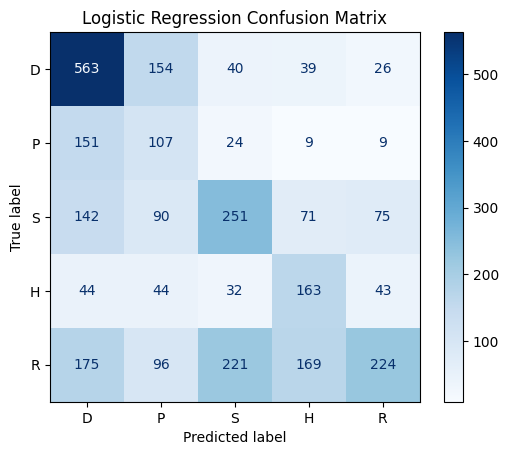

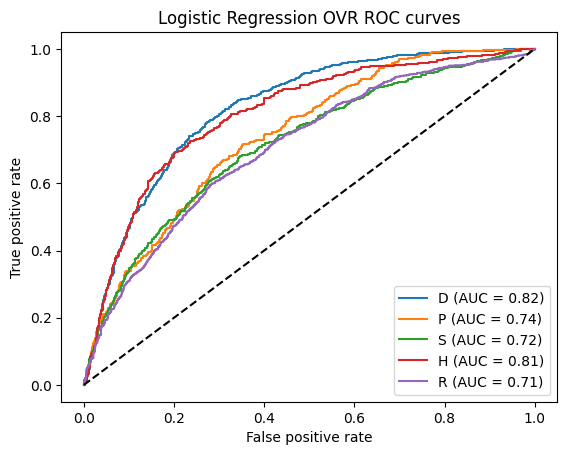

In [127]:
log_results = evaluate_model(log_csf, "Logistic Regression", X_test_scaled, y_test, 'Blues')
model_comparison_results.append(log_results)

#### Support Vector Machine

Support Vector Machine best parameters found = {'C': 10, 'gamma': 0.1}

SVM accuracy score = 0.5560432140445645

SVM classification report 
               precision    recall  f1-score   support

           D       0.61      0.74      0.67       822
           H       0.35      0.45      0.39       300
           P       0.55      0.40      0.47       629
           R       0.51      0.41      0.45       326
           S       0.60      0.59      0.59       885

    accuracy                           0.56      2962
   macro avg       0.52      0.52      0.51      2962
weighted avg       0.56      0.56      0.55      2962


SVM Metrics


,Metric,Score
0,Balanced Accuracy,0.516576
1,Macro ROC-AUC,0.815949
2,Micro ROC-AUC,0.837837


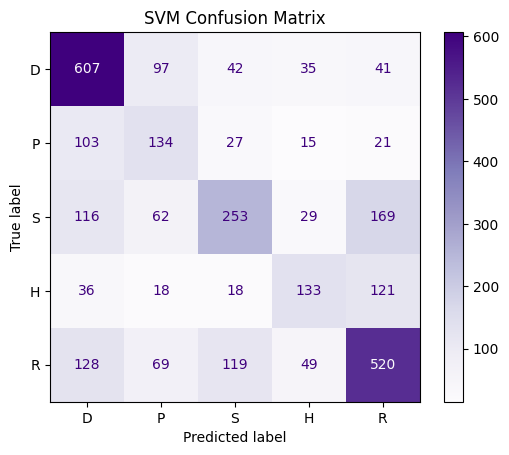

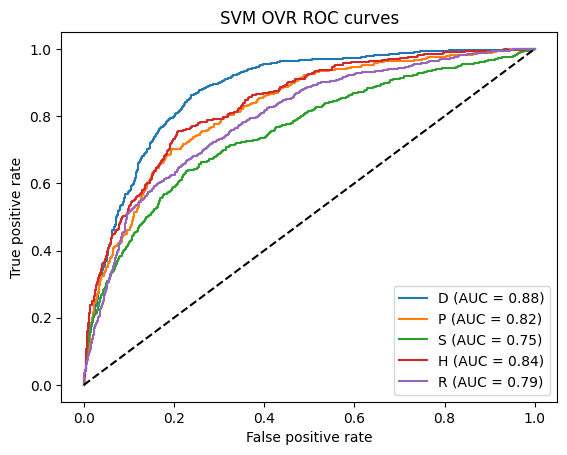

In [128]:
print("Support Vector Machine best parameters found =", grid_svm.best_params_)
svm_results = evaluate_model(grid_svm.best_estimator_, "SVM", X_test_scaled, y_test,  cmap='Purples')
model_comparison_results.append(svm_results)

#### Extra Trees Classifier

Extra Trees Classifier best parameters found = {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}

Extra Trees Classifier accuracy score = 0.7042538825118163

Extra Trees Classifier classification report 
               precision    recall  f1-score   support

           D       0.71      0.88      0.78       822
           H       0.83      0.52      0.64       300
           P       0.71      0.54      0.61       629
           R       0.70      0.55      0.62       326
           S       0.68      0.78      0.72       885

    accuracy                           0.70      2962
   macro avg       0.72      0.65      0.68      2962
weighted avg       0.71      0.70      0.70      2962


Extra Trees Classifier Metrics


,Metric,Score
0,Balanced Accuracy,0.653608
1,Macro ROC-AUC,0.911228
2,Micro ROC-AUC,0.919368


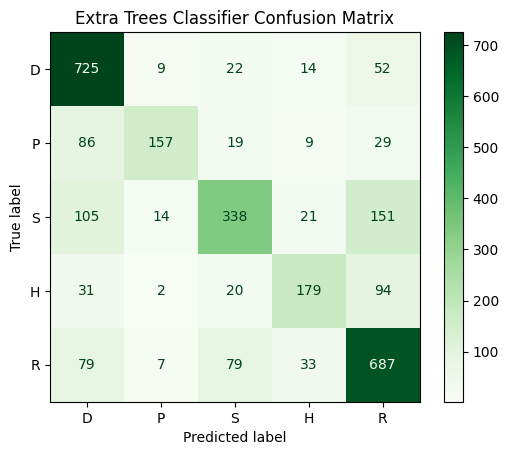

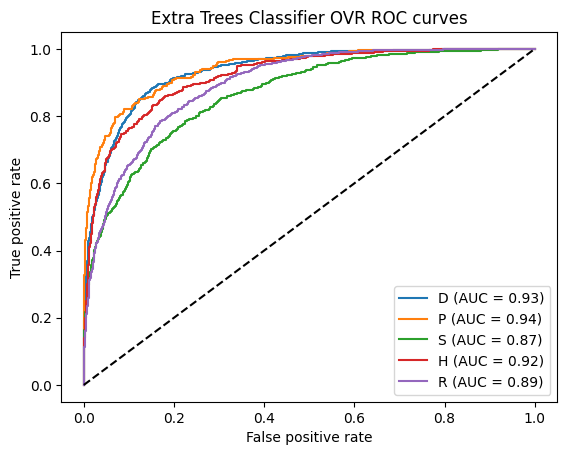

In [129]:
print("Extra Trees Classifier best parameters found =", etc_RS.best_params_)
etc_results = evaluate_model(etc_RS.best_estimator_, "Extra Trees Classifier", X_test, y_test,  cmap='Greens')
model_comparison_results.append(etc_results)

#### Light Gradient Boosting Machine

Light Gradient Boosting Machine best parameters = {'subsample': 0.7, 'reg_lambda': 0.6, 'reg_alpha': 0.1, 'num_leaves': 70, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 12, 'learning_rate': 0.085, 'colsample_bytree': 0.8, 'class_weight': 'balanced'}

LGBM accuracy score = 0.7029034436191762

LGBM classification report 
               precision    recall  f1-score   support

           D       0.76      0.85      0.80       822
           H       0.68      0.54      0.60       300
           P       0.68      0.59      0.63       629
           R       0.63      0.56      0.59       326
           S       0.69      0.75      0.72       885

    accuracy                           0.70      2962
   macro avg       0.69      0.66      0.67      2962
weighted avg       0.70      0.70      0.70      2962


LGBM Metrics


c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Metric,Score
0,Balanced Accuracy,0.658484
1,Macro ROC-AUC,0.910416
2,Micro ROC-AUC,0.921034


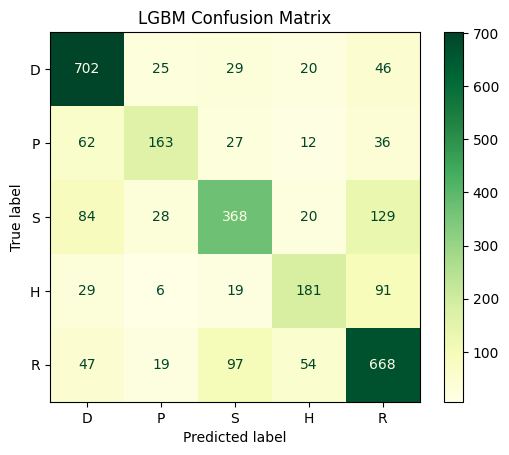

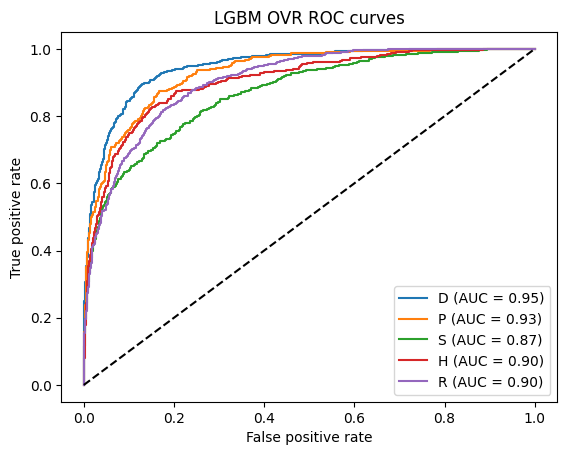

In [130]:
print("Light Gradient Boosting Machine best parameters =", lgbm_RS.best_params_)
lgbm_results = evaluate_model(lgbm_RS.best_estimator_, 'LGBM', X_test, y_test, cmap ='YlGn')
model_comparison_results.append(lgbm_results)

#### eXtreme Gradient Boosting

XGBoost best parameters found = {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 11, 'learning_rate': 0.07, 'gamma': 0.01, 'colsample_bytree': 1.0}

XGBoost accuracy score = 0.7066171505739365

XGBoost classification report 
               precision    recall  f1-score   support

           0       0.73      0.87      0.80       822
           1       0.73      0.52      0.61       300
           2       0.70      0.57      0.63       629
           3       0.68      0.49      0.57       326
           4       0.68      0.79      0.73       885

    accuracy                           0.71      2962
   macro avg       0.70      0.65      0.67      2962
weighted avg       0.71      0.71      0.70      2962


XGBoost Metrics


,Metric,Score
0,Balanced Accuracy,0.648809
1,Macro ROC-AUC,0.911082
2,Micro ROC-AUC,0.920706


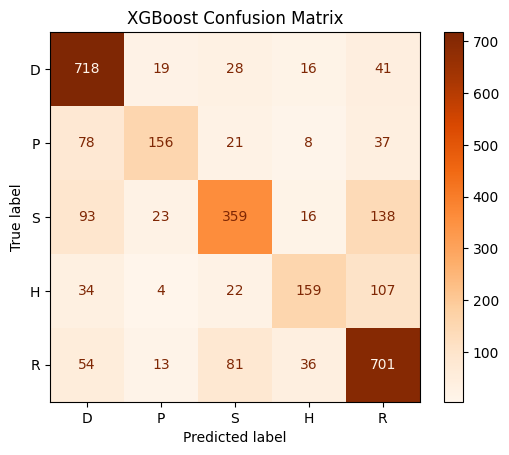

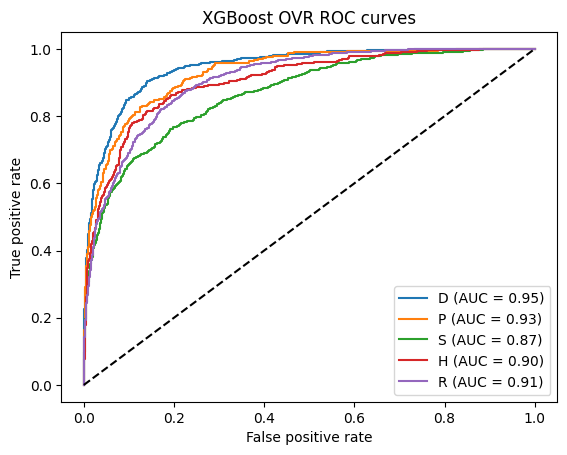

In [131]:
print("XGBoost best parameters found =", xgb_RS.best_params_)
xgbc_results = evaluate_model(xgb_RS.best_estimator_, "XGBoost", X_test, y_test_encoded,  cmap='Oranges')
model_comparison_results.append(xgbc_results)

#### XGBoost + SMOTE balancing

XGBoost (SMOTE balanced) best parameters found = {'xgbc__subsample': 0.7, 'xgbc__n_estimators': 400, 'xgbc__min_child_weight': 1, 'xgbc__max_depth': 12, 'xgbc__learning_rate': 0.07, 'xgbc__gamma': 0.0, 'xgbc__colsample_bytree': 0.8, 'smote__k_neighbors': 9}

XGBoost (SMOTE balanced) accuracy score = 0.7022282241728561

XGBoost (SMOTE balanced) classification report 
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       822
           1       0.62      0.63      0.62       300
           2       0.68      0.58      0.63       629
           3       0.58      0.61      0.60       326
           4       0.72      0.72      0.72       885

    accuracy                           0.70      2962
   macro avg       0.67      0.68      0.67      2962
weighted avg       0.70      0.70      0.70      2962


XGBoost (SMOTE balanced) Metrics


,Metric,Score
0,Balanced Accuracy,0.676186
1,Macro ROC-AUC,0.911729
2,Micro ROC-AUC,0.920748


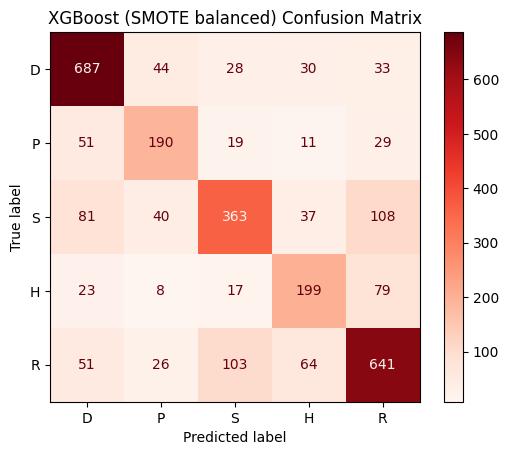

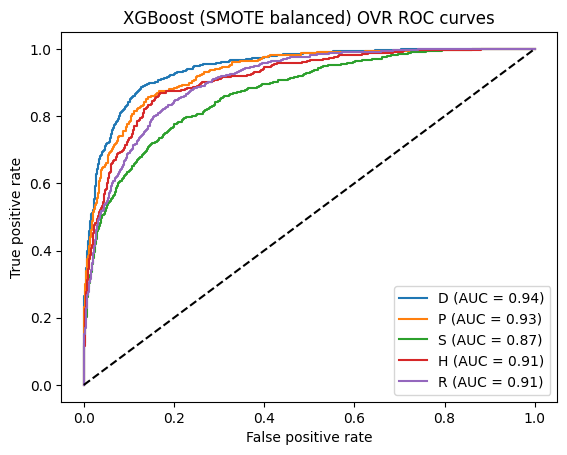

In [132]:
print("XGBoost (SMOTE balanced) best parameters found =", xgbc_smote_RS.best_params_)
xgbc_smote_results = evaluate_model(xgbc_smote_RS.best_estimator_, "XGBoost (SMOTE balanced)", X_test, y_test_encoded,  cmap='Reds')
model_comparison_results.append(xgbc_smote_results)

#### LGBM + Feature Implementation


LGBM (Feature implemented) accuracy score = 0.7079675894665767

LGBM (Feature implemented) classification report 
               precision    recall  f1-score   support

           D       0.75      0.86      0.80       822
           H       0.71      0.56      0.63       300
           P       0.68      0.59      0.63       629
           R       0.63      0.53      0.57       326
           S       0.71      0.76      0.73       885

    accuracy                           0.71      2962
   macro avg       0.69      0.66      0.67      2962
weighted avg       0.70      0.71      0.70      2962


LGBM (Feature implemented) Metrics


c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Metric,Score
0,Balanced Accuracy,0.661721
1,Macro ROC-AUC,0.912386
2,Micro ROC-AUC,0.922237


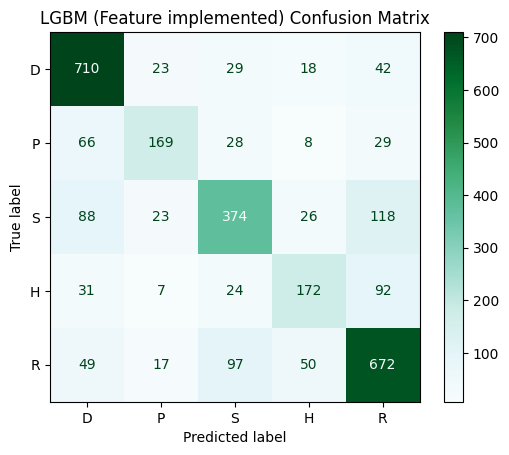

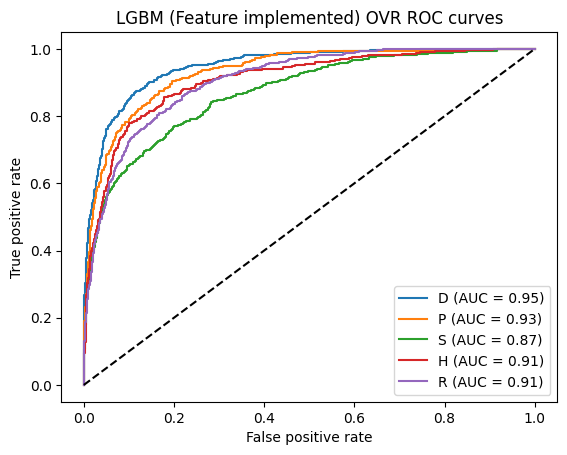

In [133]:
lgbm_FI_results = evaluate_model(lgbm_FI, "LGBM (Feature implemented)", X_test_augmented, y_test,  cmap='BuGn')
model_comparison_results.append(lgbm_FI_results)

#### Voting Classifier

c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier accuracy score = 0.7099932478055369

Voting Classifier classification report 
               precision    recall  f1-score   support

           D       0.75      0.86      0.80       822
           H       0.68      0.55      0.61       300
           P       0.70      0.59      0.64       629
           R       0.63      0.55      0.59       326
           S       0.71      0.76      0.74       885

    accuracy                           0.71      2962
   macro avg       0.69      0.66      0.68      2962
weighted avg       0.71      0.71      0.70      2962


Voting Classifier Metrics


c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Metric,Score
0,Balanced Accuracy,0.663913
1,Macro ROC-AUC,0.917245
2,Micro ROC-AUC,0.925886


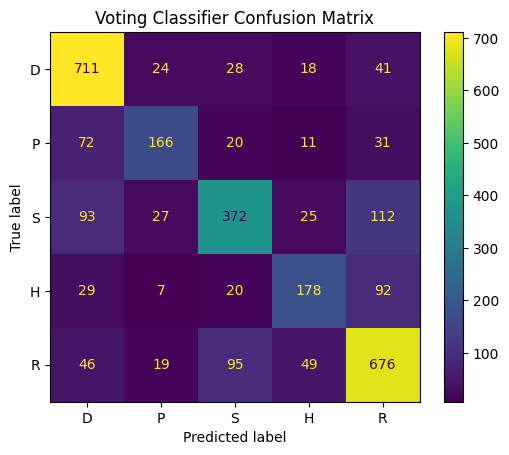

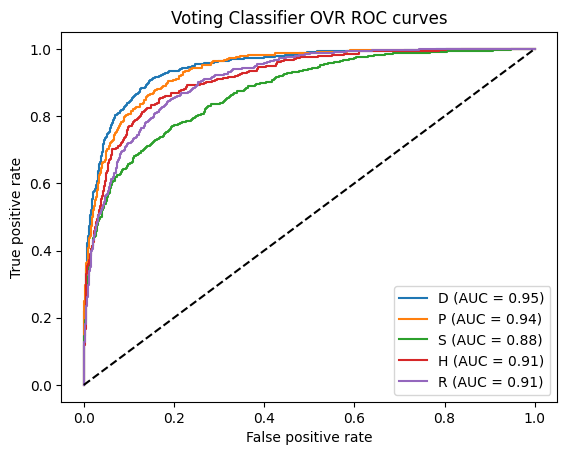

In [134]:
voting_results = evaluate_model(voting_clsf, 'Voting Classifier', X_test_augmented, y_test,  cmap='viridis')
model_comparison_results.append(voting_results)

### Model Comparison

#### Metrics summary

In [135]:
metrics_summary = pd.DataFrame([
    {'Model': r['model_name'], **r['metrics']}
    for r in model_comparison_results
])

print ("--- Model Comparison: Metrics ---")
display(metrics_summary)

--- Model Comparison: Metrics ---


,Model,Balanced Accuracy,Macro ROC-AUC,Micro ROC-AUC
0,Logistic Regression,0.438747,0.758618,0.755080
1,SVM,0.516576,0.815949,0.837837
2,Extra Trees Classifier,0.653608,0.911228,0.919368
3,LGBM,0.658484,0.910416,0.921034
4,XGBoost,0.648809,0.911082,0.920706
5,XGBoost (SMOTE balanced),0.676186,0.911729,0.920748
6,LGBM (Feature implemented),0.661721,0.912386,0.922237
7,Voting Classifier,0.663913,0.917245,0.925886


#### Macro-Average ROC

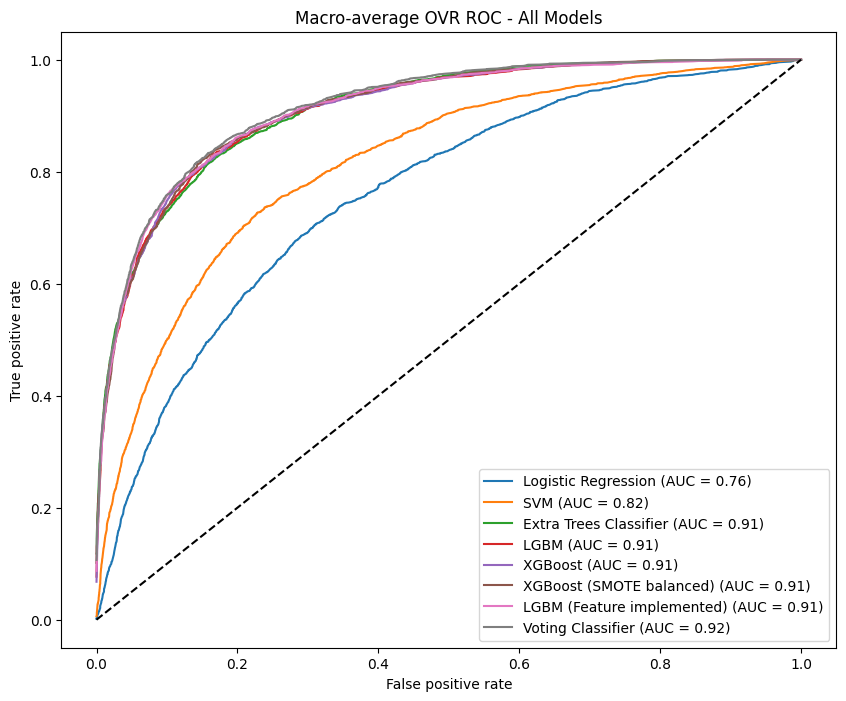

In [136]:
plt.figure(figsize=(10,8))
for r in model_comparison_results:
    fpr, tpr =  r['macro_roc']
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{r['model_name']} (AUC = {auc_val:.2f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Macro-average OVR ROC - All Models')
plt.legend()
plt.show()

#### Micro-Average ROC

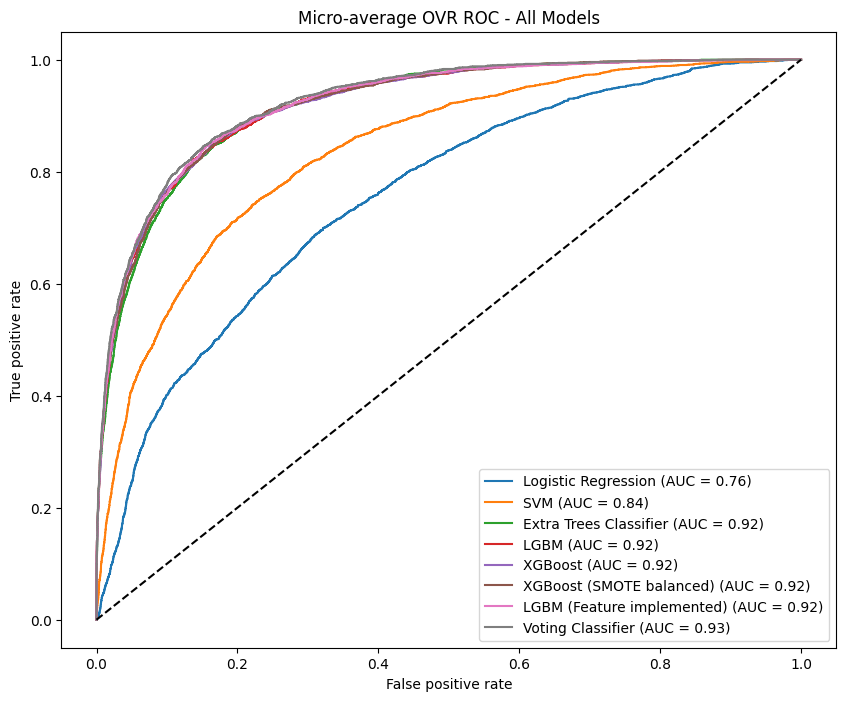

In [137]:
plt.figure(figsize=(10,8))
for r in model_comparison_results:
    fpr, tpr = r['micro_roc']
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC = {auc_val:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Micro-average OVR ROC - All Models')
plt.legend()
plt.show()

#### Per-class ROC

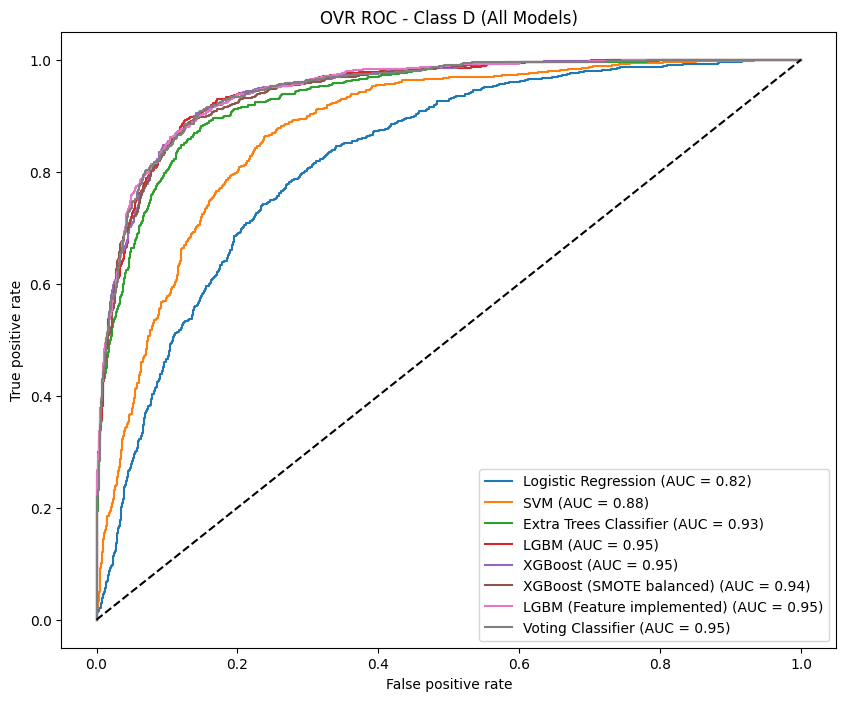

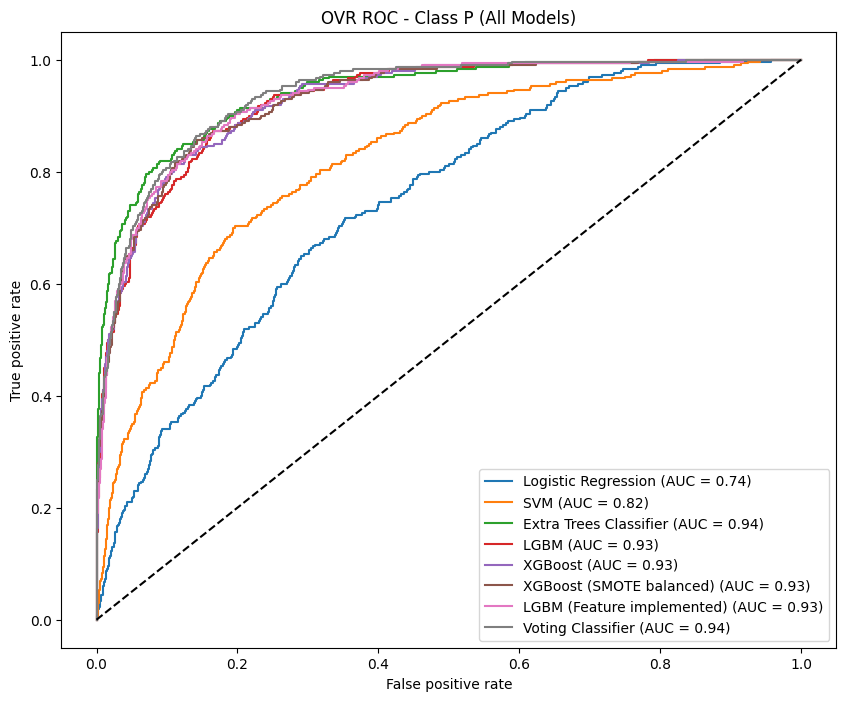

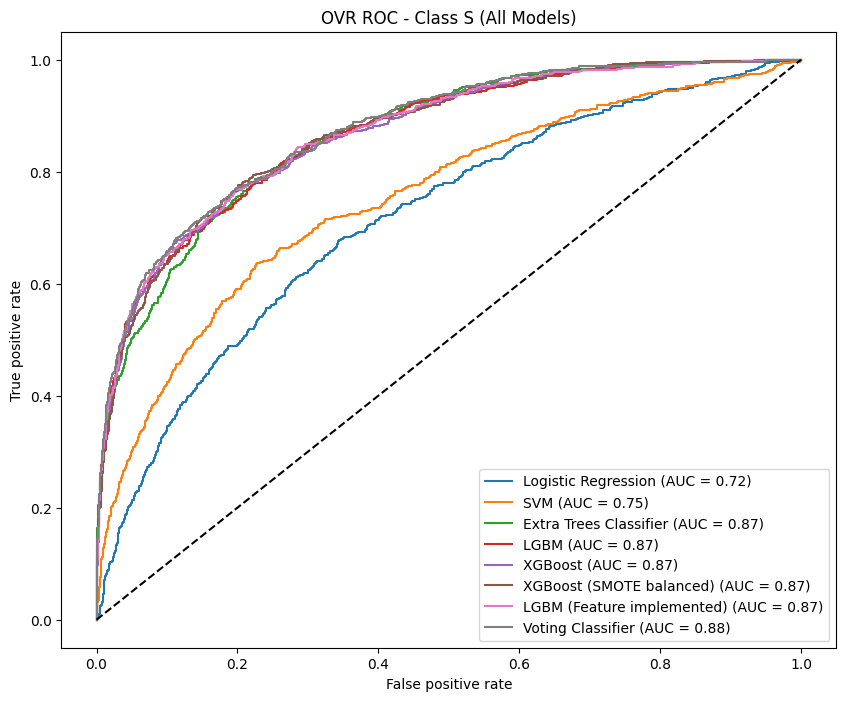

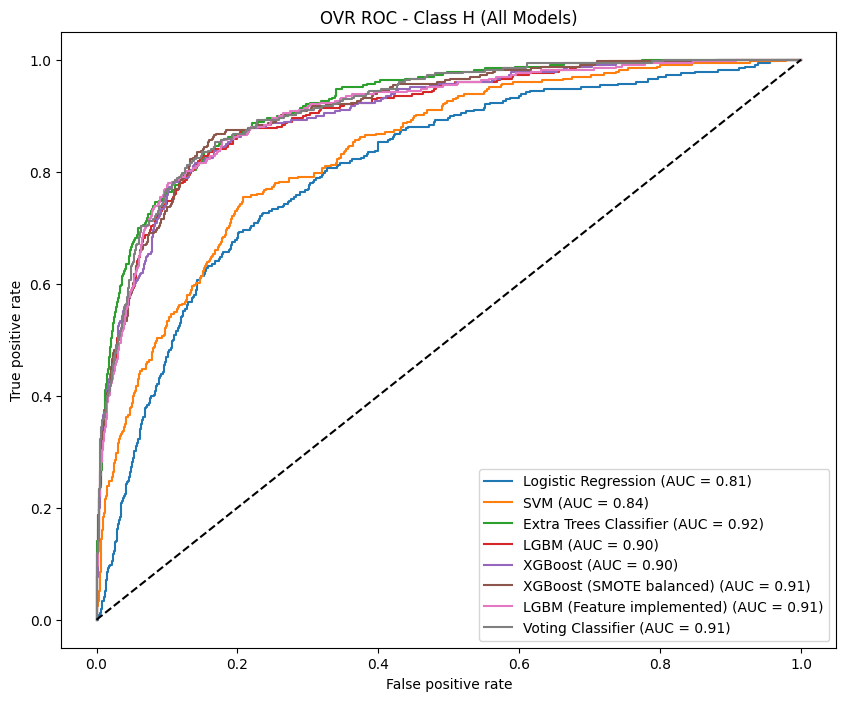

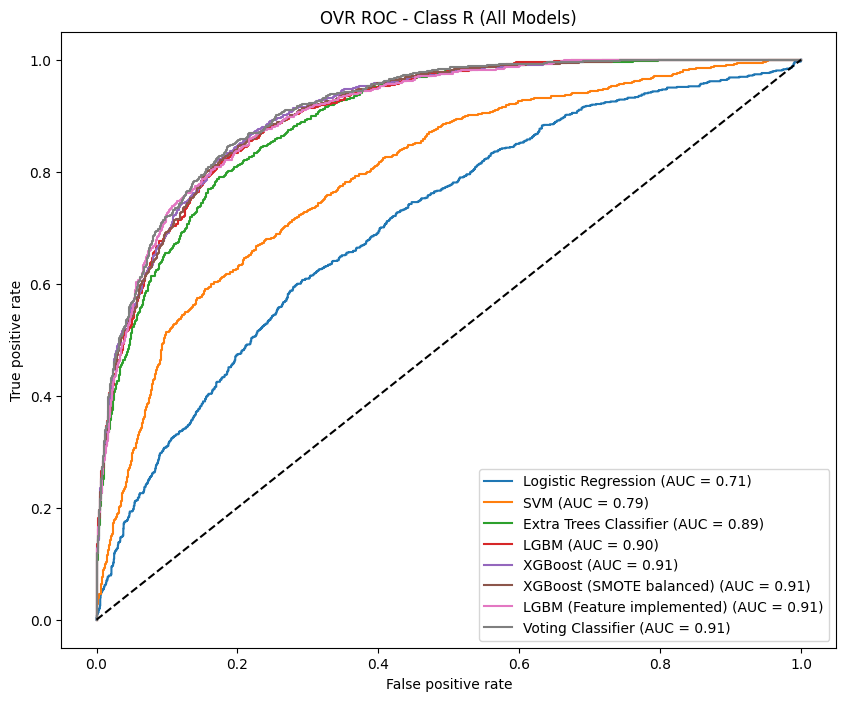

In [138]:
for cls in classes:
    plt.figure(figsize=(10,8))
    for r in model_comparison_results:
        fpr, tpr = r['roc_data'][cls]
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC = {auc_val:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'OVR ROC - Class {cls} (All Models)')
    plt.legend()
    plt.show()

## Appendix

### References

### Acknowledgement of AI contribution
This coursework used DeepSeek and GPT tools to assist in the production of the coursework in the following:


#### Examples
1. (Daniel) Clarifying documentation and concepts - I asked for explanations of specific functions and parameters from relevant libraries like scikit-learn, LightGBM, imblearn, and XGBoost from their respective official documentation which helped me understand my workset and familiarise better with concepts.
2. (Daniel) Debugging assistance - When encountering syntax errors and other warnings during cell debugging, I passed the error messages and described the issues to receive suggestions on identifying the mistakes and suggestions from future prevention.

#### Code generated
1. (Daniel) - Based on analysis of the dataset, I hypothesised that the features of the dot product of the hand-wrist coordination, as well as the asymmetry in hand movement could be useful features.
I asked DeepSeek to provide formulas which could adapt to the values present in the dataset.
It responded with the formulas present in the Data analysis section which proposes the features to implement
For the dot products:

    #Left dot
    left_dot = (df['X1'] * df['X7']+
            df['X2'] * df['X8']+
            df['X3'] * df['X9'])
    
    #Right dot
     right_dot = (df['X4'] * df['X10']+
            df['X5'] * df['X11']+
            df['X6'] * df['X12'])
    
And for the velocity ratio:

    epsilon = 1e-8
    left_right_vel_ratio = df['X25'] / (df['X26'] + epsilon)
    plt.yscale('log')
    